# 🎨 Matplotlib

Matplotlib is the foundational Python library for **data visualization**, integrating seamlessly with **NumPy** and **Pandas**. 

**Official documentation**: [User Guide](https://matplotlib.org/stable/users/index.html) · [Tutorials](https://matplotlib.org/stable/tutorials/index.html) · [Gallery](https://matplotlib.org/stable/gallery/index.html) · [Pyplot](https://matplotlib.org/stable/api/pyplot_summary.html) · [Figure/Axes API](https://matplotlib.org/stable/users/explain/figure/api_interfaces.html)

## Contents
1) Setup and imports
2) Core plots: line, scatter, bar, stacked bar, area, step, stem, error bars  
3) Distributions: histogram, 2D hist, hexbin, box, violin, KDE  
4) Contours, images & heatmaps (`imshow`, `pcolormesh`)  
5) Colors, colormaps, normalization, colorbars  
6) Axes control: ticks, locators, formatters, scales, limits, grids, spines  
7) Layouts: `subplots`, `subplot_mosaic`, `GridSpec`, insets, broken axes  
8) Shared axes, twin axes, secondary axes  
9) Dates & categoricals  
10) Text, mathtext, annotations, legends  
11) Styles, rcParams, color cycles  
12) 3D plotting  
13) Saving & exporting

## 1) Setup and imports
References: [Backends](https://matplotlib.org/stable/users/explain/figure/backends.html) · [OO vs Pyplot](https://matplotlib.org/stable/users/explain/figure/api_interfaces.html)

In [332]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker, colors
from matplotlib.dates import DateFormatter
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from matplotlib.widgets import Slider, CheckButtons
import datetime as dt

rng = np.random.default_rng(123)

## 2) Core plots: line, scatter, bar, stacked bar, area, step, stem, error bars
References: [Line/Scatter](https://matplotlib.org/stable/gallery/lines_bars_and_markers/index.html) · [Bar/Stacked](https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_stacked.html) · [Area/Fill](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.fill_between.html) · [Errorbar](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.errorbar.html)

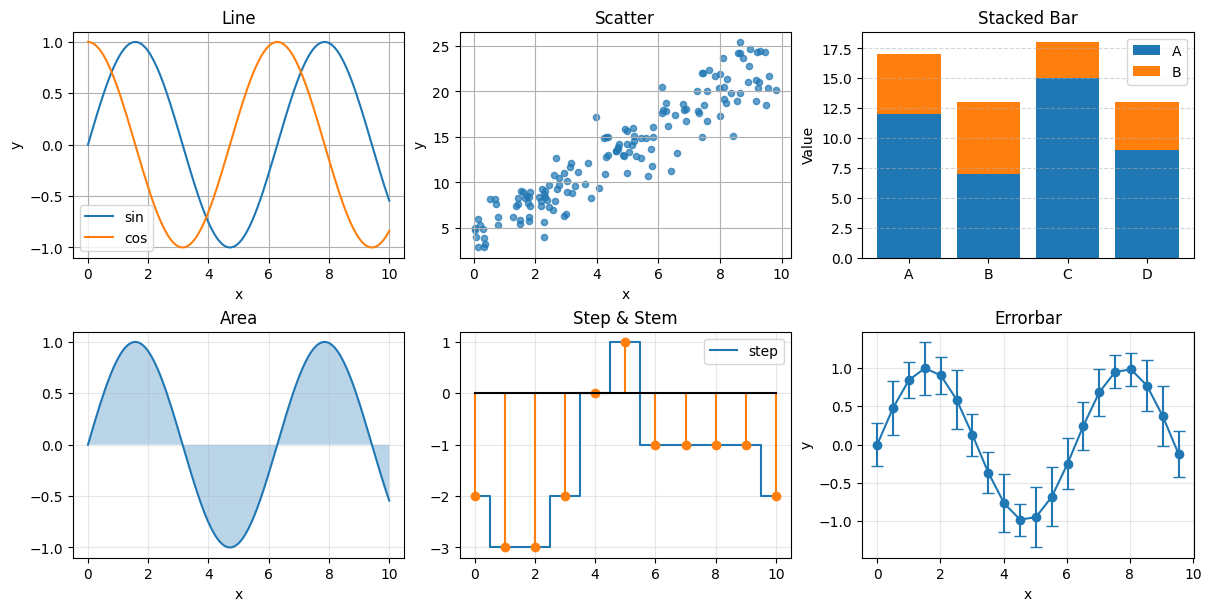

In [333]:
x = np.linspace(0, 10, 200)    # 200 points from 0 to 10
y1 = np.sin(x)                 # sin curve
y2 = np.cos(x)                 # cos curve

# Create a figure with a 2x3 array of Axes; auto-manage spacing with constrained_layout
fig, axs = plt.subplots(2, 3, figsize=(12, 6), constrained_layout=True)

# --------------------------------------------
# Example (1): Line plot
# --------------------------------------------
# Two lines on the same axes; legend distinguishes sin vs cos
axs[0,0].plot(x, y1, label='sin')
axs[0,0].plot(x, y2, label='cos')
axs[0,0].set(title='Line', xlabel='x', ylabel='y')
axs[0,0].legend()
axs[0,0].grid(True)

# --------------------------------------------
# Example (2): Scatter plot
# --------------------------------------------
# Synthetic linear relationship with noise
xs = rng.uniform(0, 10, 150)                     # random x in [0, 10]
ys = 2*xs + 4 + rng.normal(0, 2, 150)            # y = 2x + 4 + noise
axs[0,1].scatter(xs, ys, s=20, alpha=0.7)        # s: marker size; alpha: transparency
axs[0,1].set(title='Scatter', xlabel='x', ylabel='y')
axs[0,1].grid(True)

# --------------------------------------------
# Example (3): Stacked bar chart
# --------------------------------------------
# Two series stacked to show part-to-whole per category
cats = ['A','B','C','D']
a = [12, 7, 15, 9]                               # base bar values
b = [5, 6, 3, 4]                                 # stacked on top of a
axs[0,2].bar(cats, a, label='A')
axs[0,2].bar(cats, b, bottom=a, label='B')       # bottom= aligns second series on top
axs[0,2].set(title='Stacked Bar', ylabel='Value')
axs[0,2].legend()
axs[0,2].grid(axis='y', linestyle='--', alpha=0.5)

# --------------------------------------------
# Example (4): Area chart
# --------------------------------------------
# Area under the sin curve; fill_between shades between curve and baseline (0)
axs[1,0].plot(x, y1, color='tab:blue')
axs[1,0].fill_between(x, 0, y1, alpha=0.3)
axs[1,0].set(title='Area', xlabel='x')
axs[1,0].grid(True, alpha=0.3)

# --------------------------------------------
# Example (5): Step & Stem plots
# --------------------------------------------
# Step shows discrete changes; Stem emphasizes value “spikes”
xs2 = np.arange(0, 11)
ys2 = np.cumsum(rng.integers(-2, 4, size=len(xs2)))  # random walk
axs[1,1].step(xs2, ys2, where='mid', label='step')   # where='mid' aligns steps at midpoints
axs[1,1].stem(
    xs2, ys2,
    linefmt='C1-',        # line color/style
    markerfmt='C1o',      # marker style
    basefmt='k-'          # baseline style
)
axs[1,1].set(title='Step & Stem')
axs[1,1].legend()
axs[1,1].grid(True, alpha=0.3)

# --------------------------------------------
# Example (6): Error bars
# --------------------------------------------
# Errorbar plot shows uncertainty around sampled points from the sin curve
yerr = 0.2 + 0.2 * rng.random(len(x[::10]))          # heteroscedastic errors
axs[1,2].errorbar(
    x[::10], y1[::10], yerr=yerr,
    fmt='o-',                                        # marker+line format string
    capsize=4                                        # caps on error bars
)
axs[1,2].set(title='Errorbar', xlabel='x', ylabel='y')
axs[1,2].grid(True, alpha=0.3)

plt.show()

## 3) Distributions: histogram, 2D hist, hexbin, box, violin, KDE
References: [Histogram](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.hist.html) · [Hexbin](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.hexbin.html) · [Box/Violin](https://matplotlib.org/stable/gallery/statistics/index.html)

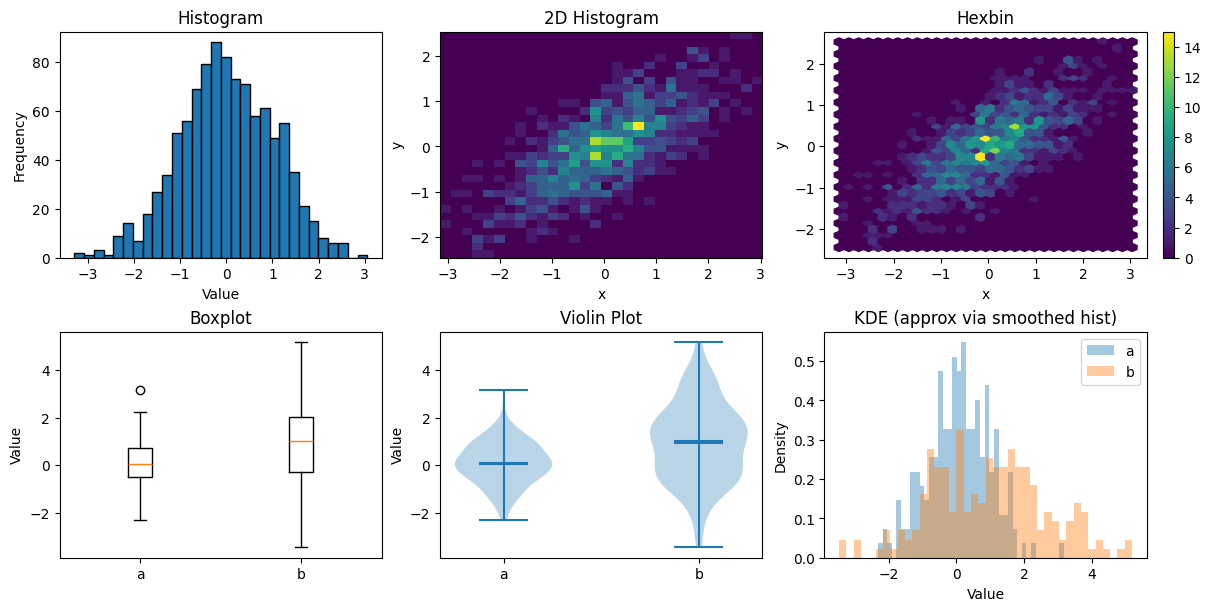

In [334]:
# Generate random normally distributed data
data = rng.normal(0, 1, 1000)                    # 1D data: mean=0, std=1
x2 = rng.normal(0, 1, 1000)                      # independent variable
y2 = x2 * 0.6 + rng.normal(0, 0.6, 1000)         # correlated variable with some noise

# Create a 2x3 grid of subplots
fig, axs = plt.subplots(2, 3, figsize=(12, 6), constrained_layout=True)

# --------------------------------------------
# Example (1): Histogram
# --------------------------------------------
# Shows the frequency distribution of one variable.
axs[0,0].hist(data, bins=30, edgecolor='black')
axs[0,0].set(title='Histogram', xlabel='Value', ylabel='Frequency')

# --------------------------------------------
# Example (2): 2D Histogram
# --------------------------------------------
# Displays joint distribution of two variables by counting how often pairs fall in 2D bins.
axs[0,1].hist2d(x2, y2, bins=30)
axs[0,1].set(title='2D Histogram', xlabel='x', ylabel='y')

# --------------------------------------------
# Example (3): Hexbin Plot
# --------------------------------------------
# Similar to a 2D histogram but uses hexagonal bins for smoother appearance.
hb = axs[0,2].hexbin(x2, y2, gridsize=30, cmap='viridis')
fig.colorbar(hb, ax=axs[0,2])                    # colorbar shows density values
axs[0,2].set(title='Hexbin', xlabel='x', ylabel='y')

# --------------------------------------------
# Example (4): Boxplot
# --------------------------------------------
# Summarizes data distribution using quartiles (min, Q1, median, Q3, max).
a = rng.normal(0, 1, 200)                        # sample 1
b = rng.normal(1, 1.5, 200)                      # sample 2
axs[1,0].boxplot([a, b], tick_labels=['a', 'b'])
axs[1,0].set(title='Boxplot', ylabel='Value')

# --------------------------------------------
# Example (5): Violin Plot
# --------------------------------------------
# Combines a boxplot with a kernel density estimate for richer distribution shape visualization.
axs[1,1].violinplot(
    [a, b],
    showmeans=True,                              # mark mean line
    showmedians=True                             # mark median line
)
axs[1,1].set_xticks([1, 2], labels=['a', 'b'])
axs[1,1].set(title='Violin Plot', ylabel='Value')

# --------------------------------------------
# Example (6): Approximate KDE via Histogram Smoothing
# --------------------------------------------
# A simple way to approximate a density curve using histograms.
axs[1,2].hist(a, bins=40, density=True, alpha=0.4, label='a')
axs[1,2].hist(b, bins=40, density=True, alpha=0.4, label='b')
axs[1,2].set(title='KDE (approx via smoothed hist)', xlabel='Value', ylabel='Density')
axs[1,2].legend()

plt.show()

## 4) Contours, images & heatmaps
`imshow` for images & heatmaps, `contour/contourf` for isolines, `pcolormesh` for gridded/quadrilateral meshes.  
References: [imshow](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.imshow.html) · [contour](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.contour.html) · [pcolormesh](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.pcolormesh.html)

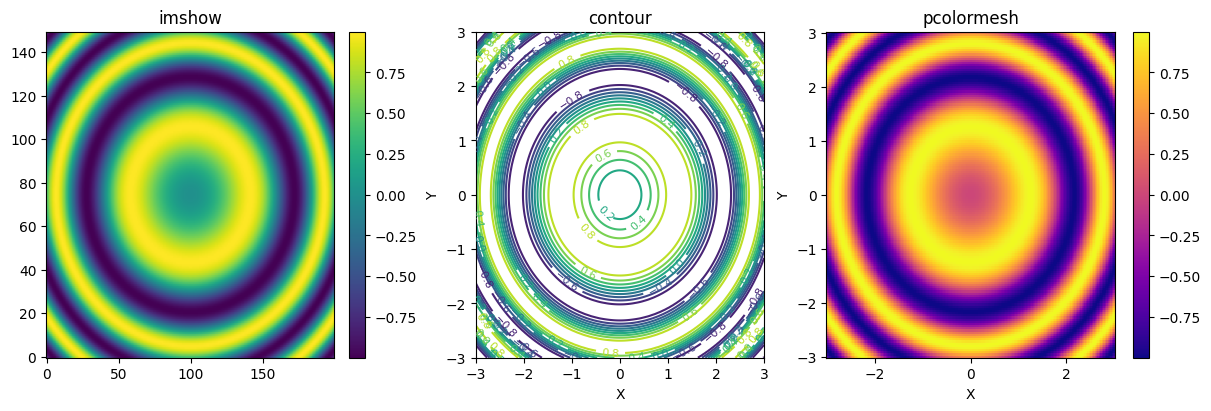

In [335]:
# Create a 2D grid of x and y coordinates
x = np.linspace(-3, 3, 200)     # 200 points from -3 to 3 (x-axis)
y = np.linspace(-3, 3, 150)     # 150 points from -3 to 3 (y-axis)
X, Y = np.meshgrid(x, y)        # create coordinate matrices (grid of x-y pairs)

# Compute Z values for each (x, y) point
Z = np.sin(X**2 + Y**2)

# Create a 1x3 grid of subplots to compare visualization techniques
fig, axs = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)

# --------------------------------------------
# Example (1): imshow
# --------------------------------------------
# Displays the 2D array as an image — each cell color represents a Z value.
im = axs[0].imshow(
    Z,
    origin='lower',             # place (0,0) at the bottom left
    cmap='viridis',             # color palette
    aspect='auto'               # adjust aspect ratio automatically
)
axs[0].set(title='imshow')
fig.colorbar(im, ax=axs[0])     # add colorbar showing Z-value scale

# --------------------------------------------
# Example (2): contour
# --------------------------------------------
# Draws contour lines (curves of constant Z value).
cs = axs[1].contour(X, Y, Z, levels=10)         # 10 contour levels
axs[1].clabel(cs, inline=True, fontsize=8)      # add labels directly on contour lines
axs[1].set(title='contour', xlabel='X', ylabel='Y')

# --------------------------------------------
# Example (3): pcolormesh
# --------------------------------------------
# Similar to imshow, but works with actual coordinate grids (X, Y).
# Each grid cell is colored according to the Z value.
pcm = axs[2].pcolormesh(
    X, Y, Z,
    shading='auto',                             # smooth shading to avoid edge artifacts
    cmap='plasma'                               # different color map for comparison
)
axs[2].set(title='pcolormesh', xlabel='X', ylabel='Y')
fig.colorbar(pcm, ax=axs[2])                    # add colorbar for value reference

plt.show()

## 5) Colors, colormaps, normalization, colorbars
Prefer perceptually uniform colormaps (`viridis`, `plasma`, `cividis`). Use `Normalize`, `LogNorm`, `TwoSlopeNorm` to map data ranges to colors.  
References: [Colors](https://matplotlib.org/stable/tutorials/colors/colors.html) · [Colormaps](https://matplotlib.org/stable/tutorials/colors/colormaps.html) · [Normalize API](https://matplotlib.org/stable/api/colors_api.html)

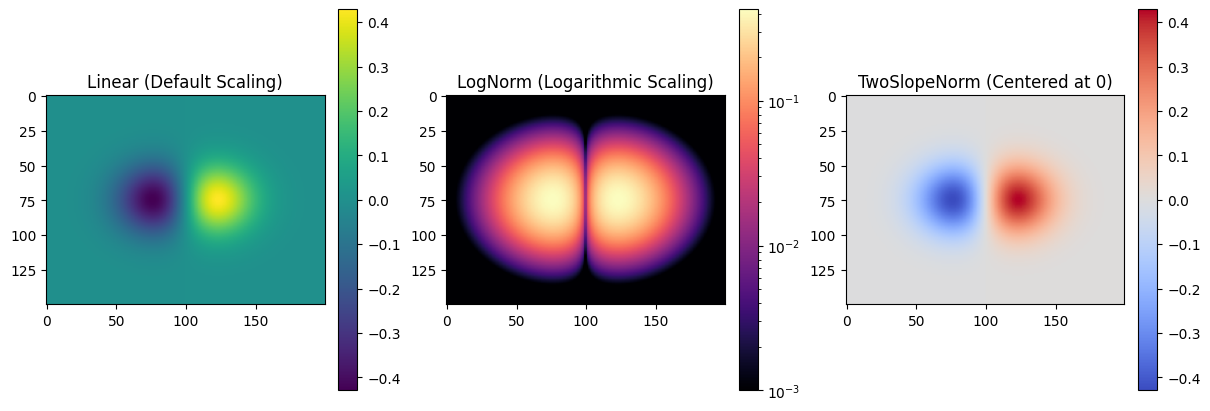

In [336]:
Z = X*np.exp(-X**2 - Y**2)

# Create a 1x3 grid of subplots for comparison
fig, axs = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)

# --------------------------------------------
# Example (1): Linear normalization
# --------------------------------------------
# Default color scaling (maps Z values linearly to colors)
im0 = axs[0].imshow(Z, cmap='viridis')
axs[0].set(title='Linear (Default Scaling)')
fig.colorbar(im0, ax=axs[0])

# --------------------------------------------
# Example (2): Logarithmic normalization
# --------------------------------------------
# Useful for data with wide value ranges (positive only).
im1 = axs[1].imshow(
    np.abs(Z),                                            # use absolute values
    cmap='magma',                                         # fiery color map
    norm=colors.LogNorm(vmin=1e-3, vmax=np.abs(Z).max())  # log scale between 1e-3 and max(|Z|)
)
axs[1].set(title='LogNorm (Logarithmic Scaling)')
fig.colorbar(im1, ax=axs[1])

# --------------------------------------------
# Example (3): Diverging (centered) normalization
# --------------------------------------------
# `TwoSlopeNorm` centers the color map at a midpoint (e.g., zero)
# Negative values → one color, positive → another color
im2 = axs[2].imshow(
    Z,
    cmap='coolwarm',  # blue for negatives, red for positives
    norm=colors.TwoSlopeNorm(vmin=Z.min(), vcenter=0, vmax=Z.max())
)
axs[2].set(title='TwoSlopeNorm (Centered at 0)')
fig.colorbar(im2, ax=axs[2])

plt.show()

## 6) Axes control: ticks, locators, formatters, scales, limits, grids, spines
References: [Ticker API](https://matplotlib.org/stable/api/ticker_api.html) · [Scales](https://matplotlib.org/stable/users/explain/axes/scales.html) · [Legends](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.legend.html)

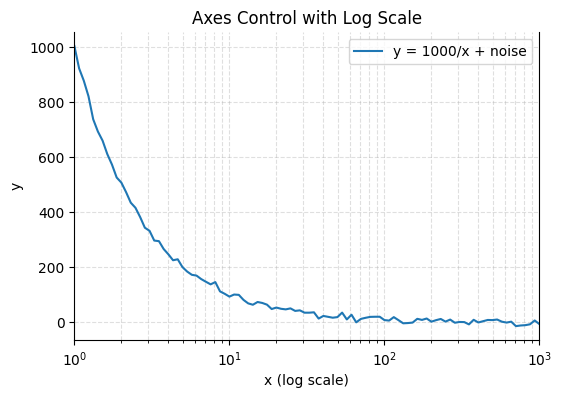

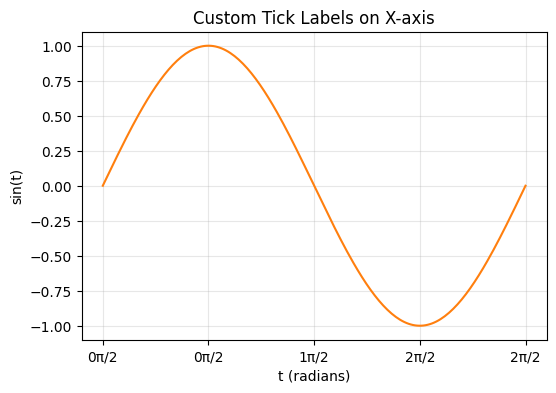

In [337]:
# --------------------------------------------
# Example (1): Controlling Axes and Scales
# --------------------------------------------
# Generate x values on a logarithmic scale (10⁰ to 10³)
x = np.logspace(0, 3, 100)

# Define y = 1000/x with small random noise
rng = np.random.default_rng(42)
y = 1e3 / x + rng.normal(0, 10, 100)

# Create a figure and axis
fig, ax = plt.subplots(figsize=(6, 4))

# Plot the data with a label for the legend
ax.plot(x, y, label='y = 1000/x + noise', color='tab:blue')

# Set logarithmic x-axis to show exponential scale clearly
ax.set_xscale('log')
ax.set_xlim(1, 1000)

# Add labels, title, and style adjustments
ax.set(
    title='Axes Control with Log Scale',
    xlabel='x (log scale)',
    ylabel='y'
)

# Customize appearance
ax.grid(True, which='both', linestyle='--', alpha=0.4)  # show major & minor gridlines
ax.legend()                                             # show legend box
ax.spines['top'].set_visible(False)                     # remove top border for cleaner look

plt.show()


# --------------------------------------------
# Example (2): Custom Tick Formatting
# --------------------------------------------
# Generate t values from 0 to 2π
t = np.linspace(0, 2 * np.pi, 200)

# Create a new figure for sine wave
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t, np.sin(t), color='tab:orange')

# Major ticks every π/2 radians
ax.xaxis.set_major_locator(ticker.MultipleLocator(np.pi / 2))

# Format tick labels as multiples of π/2 (e.g., "0π/2", "1π/2", "2π/2", etc.)
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda v, pos: f"{v/np.pi:.0f}π/2")
)

# Add labels and grid
ax.set(
    title='Custom Tick Labels on X-axis',
    xlabel='t (radians)',
    ylabel='sin(t)'
)
ax.grid(True, alpha=0.3)

plt.show()

## 7) Layouts: `subplots`, `subplot_mosaic`, `GridSpec`, insets, broken axes
References: [subplots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html) · [subplot_mosaic](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplot_mosaic.html) · [GridSpec](https://matplotlib.org/stable/api/gridspec_api.html) · [Insets](https://matplotlib.org/stable/gallery/axes_grid1/inset_locator_demo.html) · [Broken axes](https://matplotlib.org/stable/gallery/subplots_axes_and_figures/broken_axis.html)

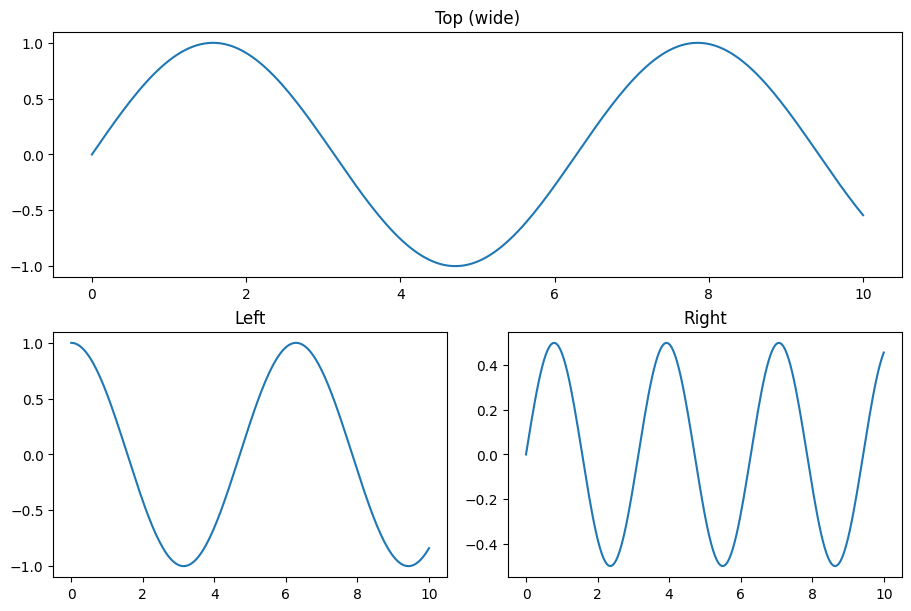

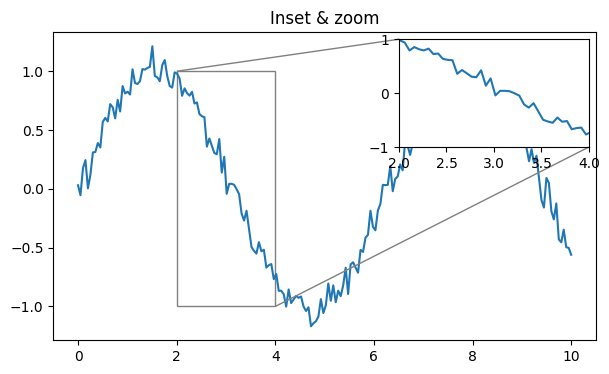

In [338]:
rng = np.random.default_rng(42)

# --------------------------------------------
# Example (1): Subplot mosaic
# --------------------------------------------
# Build a custom layout with named Axes using subplot_mosaic:
# Layout grid:
#   [ top  |  top  ]   -> one wide axis called 'top' spanning two columns
#   [ left | right ]   -> two normal axes: 'left' and 'right'
fig, axd = plt.subplot_mosaic(
    [["top", "top"],
     ["left", "right"]],
    figsize=(9, 6),
    constrained_layout=True
)

x = np.linspace(0, 10, 200)

# Plot into each named Axes
axd['top'].plot(x, np.sin(x))
axd['top'].set_title('Top (wide)')

axd['left'].plot(x, np.cos(x))
axd['left'].set_title('Left')

axd['right'].plot(x, np.sin(x) * np.cos(x))
axd['right'].set_title('Right')

plt.show()

# --------------------------------------------
# Example (2): Inset (zoom) axes
# --------------------------------------------
# Create a main axes plus a small inset axes inside it to zoom into a region.
fig, ax = plt.subplots(figsize=(7, 4))
y = np.sin(x) + 0.1 * rng.normal(size=len(x))

ax.plot(x, y)
ax.set_title('Inset & zoom')

# Create a smaller Axes inside the main one (upper-right corner).
# width/height can be percentages ('35%') or absolute units (e.g., 1.5 for inches).
axins = inset_axes(ax, width='35%', height='35%', loc='upper right')

# Plot the same data inside the inset and set the zoom window.
axins.plot(x, y)
axins.set_xlim(2, 4)    # zoomed x-range
axins.set_ylim(-1, 1)   # zoomed y-range

# Draw connectors showing which region of the main plot is being zoomed.
mark_inset(ax, axins, loc1=2, loc2=4, fc='none', ec='0.5')

plt.show()

## 8) Shared axes, twin axes, secondary axes
References: [sharex/sharey](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html) · [twinx/twiny](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.twinx.html) · [secondary axis](https://matplotlib.org/stable/gallery/subplots_axes_and_figures/secondary_axis.html)

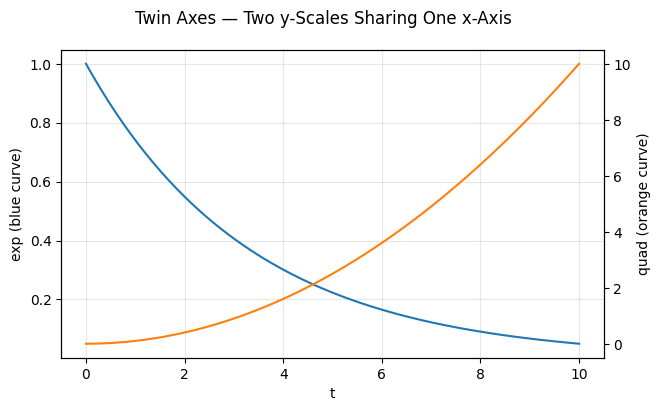

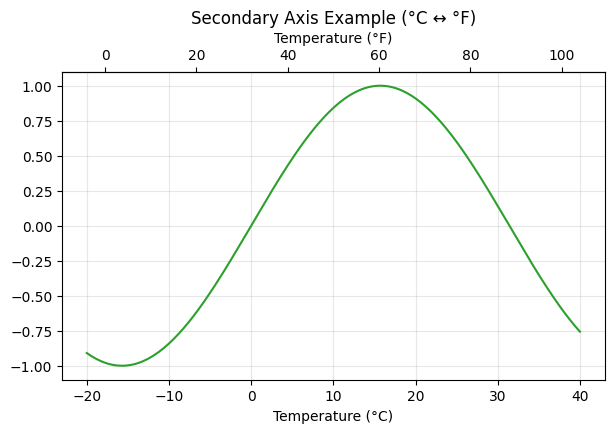

In [339]:
# --------------------------------------------
# Example (1): Twin Axes — two y-axes sharing the same x-axis
# --------------------------------------------
# Generate time values (0 to 10)
t = np.linspace(0, 10, 200)

# Two different functions with different scales
y1 = np.exp(-0.3 * t)      # exponential decay (decreases rapidly)
y2 = (t ** 2) / 10         # quadratic growth (increases rapidly)

# Create a base figure and a primary axis
fig, ax1 = plt.subplots(figsize=(7, 4))

# Create a second y-axis sharing the same x-axis
ax2 = ax1.twinx()  # right-hand side axis shares the same x range

# Plot data on each axis
ax1.plot(t, y1, color='tab:blue', label='Exponential decay')
ax2.plot(t, y2, color='tab:orange', label='Quadratic growth')

# Label axes
ax1.set_xlabel('t')
ax1.set_ylabel('exp (blue curve)')
ax2.set_ylabel('quad (orange curve)')

# Add grid and a title
ax1.grid(True, alpha=0.3)
fig.suptitle('Twin Axes — Two y-Scales Sharing One x-Axis')

plt.show()

# --------------------------------------------
# Example (2): Secondary Axis — adding a converted scale
# --------------------------------------------
# Define temperature conversion functions
def c2f(c):                     # Celsius → Fahrenheit
    return c * 9 / 5 + 32

def f2c(f):                     # Fahrenheit → Celsius
    return (f - 32) * 5 / 9

# Create a base plot (primary x-axis in °C)
fig, ax = plt.subplots(figsize=(7, 4))
c = np.linspace(-20, 40, 200)
ax.plot(c, np.sin(c / 10), color='tab:green')

# Label main axis
ax.set_xlabel('Temperature (°C)')
ax.set_title('Secondary Axis Example (°C ↔ °F)')
ax.grid(True, alpha=0.3)

# Add a secondary x-axis (top) linked by conversion functions
sec = ax.secondary_xaxis('top', functions=(c2f, f2c))
sec.set_xlabel('Temperature (°F)')

plt.show()

## 9) Dates & categoricals
References: [Dates](https://matplotlib.org/stable/gallery/text_labels_and_annotations/date.html) · [Categoricals](https://matplotlib.org/stable/gallery/lines_bars_and_markers/categorical_variables.html)

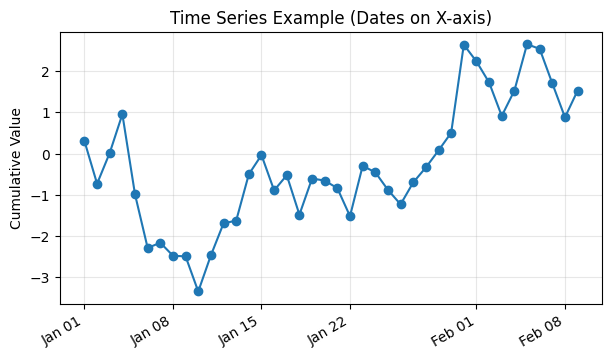

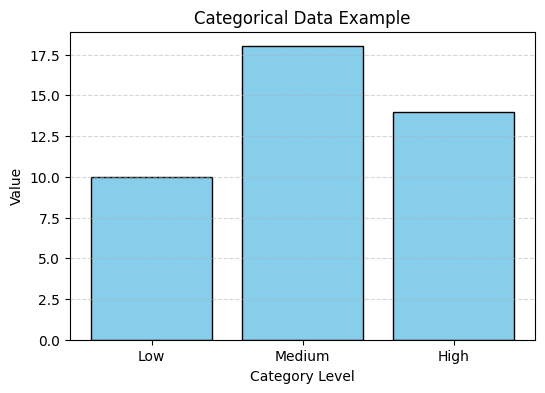

In [340]:
rng = np.random.default_rng(42)

# --------------------------------------------
# Example (1): Plotting Time Series Data (Dates on the X-axis)
# --------------------------------------------
# Define a start date
start = dt.date(2024, 1, 1)

# Generate an array of 40 consecutive daily dates
dates = np.array([start + dt.timedelta(days=i) for i in range(40)])

# Generate random cumulative data to simulate time series (like stock prices)
vals = np.cumsum(rng.normal(0, 1, size=40))

# Create a line plot with dates on the x-axis
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(dates, vals, marker='o', color='tab:blue')

# Add title, labels, and a y-axis label
ax.set(
    title='Time Series Example (Dates on X-axis)',
    ylabel='Cumulative Value'
)

# Format the date labels on the x-axis for readability
ax.xaxis.set_major_formatter(DateFormatter('%b %d'))
fig.autofmt_xdate()  # auto-rotates date labels to avoid overlap

# Add a light grid
ax.grid(True, alpha=0.3)

plt.show()

# --------------------------------------------
# Example (2): Plotting Categorical Data (Bar Chart)
# --------------------------------------------
# Define category labels and corresponding values
cats = ['Low', 'Medium', 'High']
vals = [10, 18, 14]

# Create a simple bar chart
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(cats, vals, color='skyblue', edgecolor='black')

# Add labels and title
ax.set(
    title='Categorical Data Example',
    xlabel='Category Level',
    ylabel='Value'
)

# Add gridlines only for the y-axis to improve readability
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## 10) Text, mathtext, annotations, legends
References: [Annotate](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.annotate.html) · [Text](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.text.html) · [Legends](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.legend.html) · [Mathtext](https://matplotlib.org/stable/tutorials/text/mathtext.html)

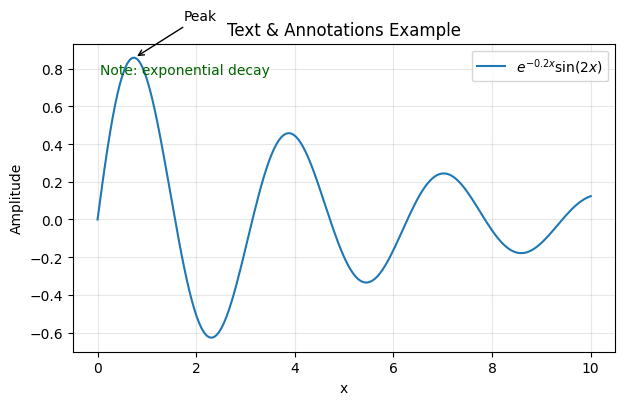

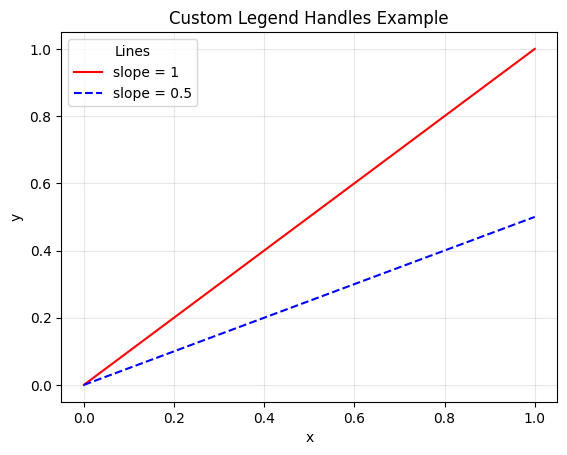

In [341]:
# --------------------------------------------
# Example (1): Text, Labels, and Annotations on a Plot
# --------------------------------------------
# Generate data
x = np.linspace(0, 10, 200)
y = np.exp(-0.2 * x) * np.sin(2 * x) 

# Create the figure and axis
fig, ax = plt.subplots(figsize=(7, 4))

# Plot the curve with a LaTeX-style label (for legend)
ax.plot(x, y, label=r'$e^{-0.2x}\sin(2x)$', color='tab:blue')

# Set title and axis labels
ax.set(
    title='Text & Annotations Example',
    xlabel='x',
    ylabel='Amplitude'
)

# Add an annotation (arrow + label pointing to a data feature)
peak = np.argmax(y)                                        # find index of the highest point in y
ax.annotate(
    'Peak',                                                # text label
    xy=(x[peak], y[peak]),                                 # point to annotate (data coords)
    xytext=(x[peak] + 1, y[peak] + 0.2),                   # position of text label
    arrowprops=dict(arrowstyle='->', color='black', lw=1)  # style of arrow
)


ax.text(
    0.05, 0.9,
    'Note: exponential decay',
    transform=ax.transAxes,
    fontsize=10,
    color='darkgreen'
)

# Add legend and grid
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()


# --------------------------------------------
# Example (2): Custom Legend Handles
# --------------------------------------------
# Plot two lines with different styles
line1, = plt.plot([0, 1], [0, 1], 'r-', label='slope = 1')       # red solid line
line2, = plt.plot([0, 1], [0, 0.5], 'b--', label='slope = 0.5')  # blue dashed line

# Manually define which plotted elements appear in the legend
plt.legend(handles=[line1, line2], title='Lines')

plt.title('Custom Legend Handles Example')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.show()

## 11) Styles, rcParams, color cycles
References: [Stylesheets](https://matplotlib.org/stable/gallery/style_sheets/style_sheets_reference.html) · [Customizing with rcParams](https://matplotlib.org/stable/tutorials/introductory/customizing.html) · [Color cycles](https://matplotlib.org/stable/tutorials/colors/colors.html#cycle-defaults)

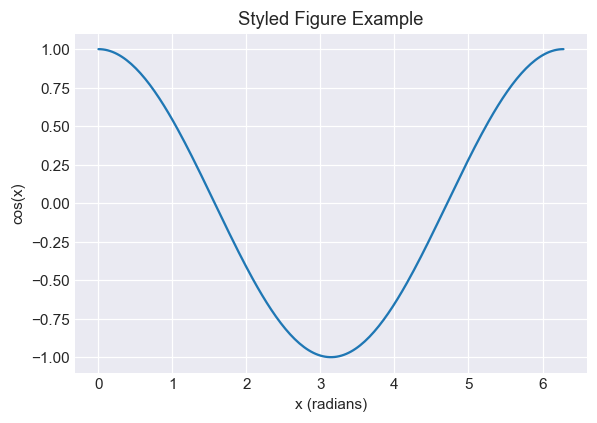

In [342]:
# --------------------------------------------
# Example (1): Applying Styles and Customizing Global Plot Settings
# --------------------------------------------
# 1) Apply a pre-defined style
plt.style.use('seaborn-v0_8-darkgrid')

# 2) Adjust rcParams for finer control over appearance
plt.rcParams['figure.dpi'] = 110           # higher DPI → sharper figures
plt.rcParams['axes.titlesize'] = 12        # control font size of titles

# 3) Create a simple plot to demonstrate the style
x = np.linspace(0, 2 * np.pi, 200)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, np.cos(x), color='tab:blue')

# 4) Add informative labels and title
ax.set(
    title='Styled Figure Example',
    xlabel='x (radians)',
    ylabel='cos(x)'
)

plt.show()
plt.style.use('default')

## 12) 3D plotting
References: [mplot3d gallery](https://matplotlib.org/stable/gallery/mplot3d/index.html)

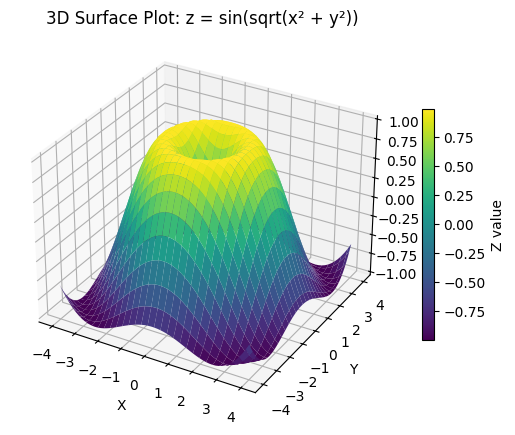

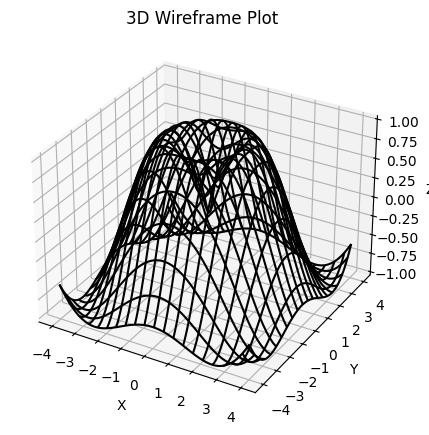

In [343]:
# --------------------------------------------
# Example (1): 3D Surface Plot
# --------------------------------------------
# Create a new figure and add a 3D axis
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')  # 111 → single subplot

# Generate 2D grid coordinates
x = np.linspace(-4, 4, 60)   # X-axis values from -4 to 4
y = np.linspace(-4, 4, 60)   # Y-axis values from -4 to 4
X, Y = np.meshgrid(x, y)     # create a coordinate grid

# Compute Z values as a function of X and Y (a circular wave pattern)
Z = np.sin(np.sqrt(X**2 + Y**2))

# Plot a smooth 3D surface with the 'viridis' color map
surf = ax.plot_surface(
    X, Y, Z,
    cmap='viridis',       # color gradient
    edgecolor='none'      # remove mesh edges for a clean surface
)

# Add labels and a colorbar to interpret heights (Z values)
ax.set(
    title='3D Surface Plot: z = sin(sqrt(x² + y²))',
    xlabel='X',
    ylabel='Y',
    zlabel='Z'
)

fig.colorbar(surf, ax=ax, shrink=0.6, label='Z value')
plt.show()

# --------------------------------------------
# Example (2): 3D Wireframe Plot
# --------------------------------------------
# Wireframe plots use grid lines instead of a solid surface
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')

# Plot a 3D wireframe; rstride/cstride control spacing between grid lines
ax.plot_wireframe(
    X, Y, Z,
    rstride=3, cstride=3,   # skip points to make the wireframe lighter
    color='black'
)

ax.set_title('3D Wireframe Plot')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()

## 13) Saving & exporting
References: [savefig](https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.savefig.html) · [Text/Fonts](https://matplotlib.org/stable/users/explain/text/text_props.html) · [usetex](https://matplotlib.org/stable/tutorials/text/usetex.html)

In [344]:
# fig, ax = plt.subplots(figsize=(6,4))
# x = np.linspace(0, 1, 100); ax.plot(x, np.sqrt(x))
# ax.set(title='y = sqrt(x)', xlabel='x', ylabel='y'); ax.grid(True, alpha=0.3)

# # Save as a PNG (raster format) — best for images on screens
# fig.savefig('sqrt.png', dpi=150, bbox_inches='tight')

# # Save as a PDF (vector format) — best for printing or reports
# fig.savefig('sqrt.pdf', bbox_inches='tight')

# # Save as an SVG (vector format) — ideal for web or scalable graphics
# fig.savefig('sqrt.svg', bbox_inches='tight')

# plt.show()